# Few-Shot Day-to-Night Translation: Main-Grid Analysis

This notebook compares Pix2Pix-Turbo and CycleGAN-Turbo across the 10-, 20-, and 50-shot settings using the 18-run RTX 5090 experiment. All runs use the same deterministic 200-image held-out test subset.

**Breaking-point definition.** For a lower shot level $L$ and the next higher level $H$, we require (1) a significant degradation in the direction of worse performance at $L$ relative to $H$, and (2) increased variability at $L$ across seeds and, when the full artifact is available, across test samples.

## Quantitative comparison

Each metric gets one panel, with both models on the same axes. Lines emphasize the shot trajectory better than grouped bars; error bars show **standard deviation across the three training seeds**, and faint points expose the individual seed values. Metric direction is shown in each title.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_rel


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'docs' / 'results_5090' / 'runs.csv').is_file():
            return candidate
    raise FileNotFoundError('Could not find docs/results_5090/runs.csv')


ROOT = find_project_root()
RESULTS = ROOT / 'docs' / 'results_5090'
runs = pd.read_csv(RESULTS / 'runs.csv')
aggregate = pd.read_csv(RESULTS / 'aggregate.csv')

SHOTS = [10, 20, 50]
MODELS = ['pix2pix', 'cyclegan']
MODEL_LABELS = {'pix2pix': 'Pix2Pix-Turbo', 'cyclegan': 'CycleGAN-Turbo'}
MODEL_COLORS = {'pix2pix': '#2C7FB8', 'cyclegan': '#E76F51'}
METRICS = {
    'ssim': {'label': 'SSIM', 'higher_is_better': True},
    'lpips': {'label': 'LPIPS', 'higher_is_better': False},
    'clip_similarity': {'label': 'CLIP similarity', 'higher_is_better': True},
    'cmmd': {'label': 'CMMD', 'higher_is_better': False},
}

assert set(runs['shot']) == set(SHOTS)
assert set(runs['model']) == set(MODELS)
assert runs.groupby(['model', 'shot'])['seed'].nunique().eq(3).all()
coverage = (
    runs.groupby(['model', 'shot'], as_index=False)
    .agg(num_seeds=('seed', 'nunique'), samples_per_seed=('num_samples', 'first'))
    .sort_values(['model', 'shot'])
)
display(coverage)

,model,shot,num_seeds,samples_per_seed
0,cyclegan,10,3,200
1,cyclegan,20,3,200
2,cyclegan,50,3,200
3,pix2pix,10,3,200
4,pix2pix,20,3,200
5,pix2pix,50,3,200


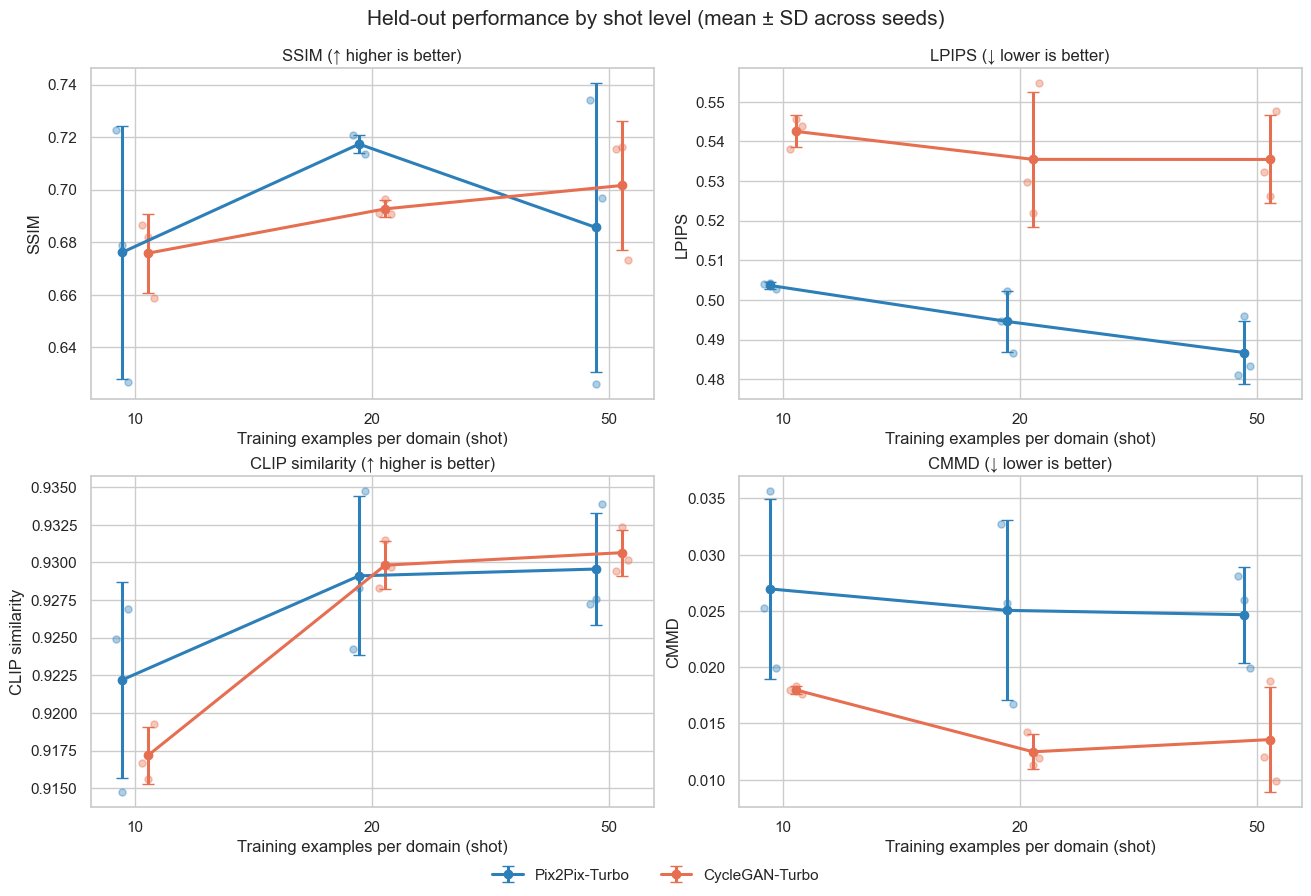

In [7]:
sns.set_theme(style='whitegrid', context='notebook')
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)
x = np.arange(len(SHOTS))
offsets = {'pix2pix': -0.055, 'cyclegan': 0.055}

for ax, (metric, meta) in zip(axes.flat, METRICS.items()):
    for model in MODELS:
        summary = (
            aggregate[(aggregate['model'] == model) & (aggregate['metric'] == metric)]
            .set_index('shot')
            .loc[SHOTS]
        )
        seed_rows = runs[runs['model'] == model]
        positions = x + offsets[model]
        ax.errorbar(
            positions, summary['mean'], yerr=summary['std_across_seeds'],
            color=MODEL_COLORS[model], marker='o', linewidth=2.2,
            capsize=4, label=MODEL_LABELS[model], zorder=3,
        )
        for index, shot in enumerate(SHOTS):
            values = seed_rows.loc[seed_rows['shot'] == shot, metric].to_numpy()
            jitter = np.linspace(-0.025, 0.025, len(values))
            ax.scatter(
                np.full(len(values), positions[index]) + jitter, values,
                s=26, color=MODEL_COLORS[model], alpha=0.38, zorder=2,
            )
    direction = '↑ higher is better' if meta['higher_is_better'] else '↓ lower is better'
    ax.set_title(f"{meta['label']} ({direction})")
    ax.set_xticks(x, SHOTS)
    ax.set_xlabel('Training examples per domain (shot)')
    ax.set_ylabel(meta['label'])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=2, frameon=False)
fig.suptitle('Held-out performance by shot level (mean ± SD across seeds)', y=1.04, fontsize=15)
plt.show()

## Breaking-point screen

For each adjacent comparison (10 vs. 20 and 20 vs. 50), metric values are oriented so that larger always means better. A positive `degradation` therefore means the lower-shot setting is worse. The mean comparison uses a one-sided paired t-test across matching seed IDs. `seed_variance_ratio > 1` means the lower-shot setting is more variable.

Because there are only three seeds, these tests have low power and should be treated as exploratory. Both raw p-values and Holm-adjusted p-values (within each model's eight adjacent-shot tests) are reported.

In [8]:
def holm_adjust(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values)
    adjusted = np.empty_like(values)
    running_max = 0.0
    total = len(values)
    for rank, index in enumerate(order):
        running_max = max(running_max, (total - rank) * values[index])
        adjusted[index] = min(running_max, 1.0)
    return adjusted


rows = []
for model in MODELS:
    model_runs = runs[runs['model'] == model]
    for metric, meta in METRICS.items():
        pivot = model_runs.pivot(index='seed', columns='shot', values=metric)
        sign = 1.0 if meta['higher_is_better'] else -1.0
        for low_shot, high_shot in ((10, 20), (20, 50)):
            low = sign * pivot[low_shot]
            high = sign * pivot[high_shot]
            degradation = float((high - low).mean())
            test = ttest_rel(high, low, alternative='greater')
            high_variance = float(high.var(ddof=1))
            low_variance = float(low.var(ddof=1))
            variance_ratio = (
                low_variance / high_variance if high_variance > 0 else np.inf
            )
            rows.append({
                'model': model,
                'metric': metric,
                'comparison': f'{low_shot} vs {high_shot}',
                'low_shot': low_shot,
                'high_shot': high_shot,
                'degradation': degradation,
                'p_raw': float(test.pvalue),
                'seed_variance_ratio': variance_ratio,
            })

breaking = pd.DataFrame(rows)
breaking['p_holm'] = breaking.groupby('model')['p_raw'].transform(holm_adjust)
breaking['mean_degrades'] = breaking['degradation'] > 0
breaking['raw_significant'] = breaking['mean_degrades'] & (breaking['p_raw'] < 0.05)
breaking['holm_significant'] = breaking['mean_degrades'] & (breaking['p_holm'] < 0.05)
breaking['seed_variance_increases'] = breaking['seed_variance_ratio'] > 1
breaking['seed_level_candidate'] = (
    breaking['raw_significant'] & breaking['seed_variance_increases']
)

display(
    breaking.sort_values(['model', 'metric', 'low_shot']).style.format({
        'degradation': '{:.4f}',
        'p_raw': '{:.4f}',
        'p_holm': '{:.4f}',
        'seed_variance_ratio': '{:.2f}',
    })
)

,model,metric,comparison,low_shot,high_shot,degradation,p_raw,seed_variance_ratio,p_holm,mean_degrades,raw_significant,holm_significant,seed_variance_increases,seed_level_candidate
12,cyclegan,clip_similarity,10 vs 20,10,20,0.0126,0.0083,1.40,0.0665,True,True,False,True,True
13,cyclegan,clip_similarity,20 vs 50,20,50,0.0008,0.0285,1.08,0.1707,True,True,False,True,True
14,cyclegan,cmmd,10 vs 20,10,20,0.0055,0.0148,0.07,0.1038,True,True,False,False,False
15,cyclegan,cmmd,20 vs 50,20,50,-0.0011,0.6159,0.11,1.0000,False,False,False,False,False
10,cyclegan,lpips,10 vs 20,10,20,0.0071,0.2758,0.06,1.0000,True,False,False,False,False
11,cyclegan,lpips,20 vs 50,20,50,0.0000,0.4981,2.37,1.0000,True,False,False,True,False
8,cyclegan,ssim,10 vs 20,10,20,0.0169,0.0866,21.48,0.4331,True,False,False,True,False
9,cyclegan,ssim,20 vs 50,20,50,0.0089,0.2857,0.02,1.0000,True,False,False,False,False
4,pix2pix,clip_similarity,10 vs 20,10,20,0.0069,0.1180,1.53,0.7082,True,False,False,True,False
5,pix2pix,clip_similarity,20 vs 50,20,50,0.0005,0.3773,2.01,1.0000,True,False,False,True,False


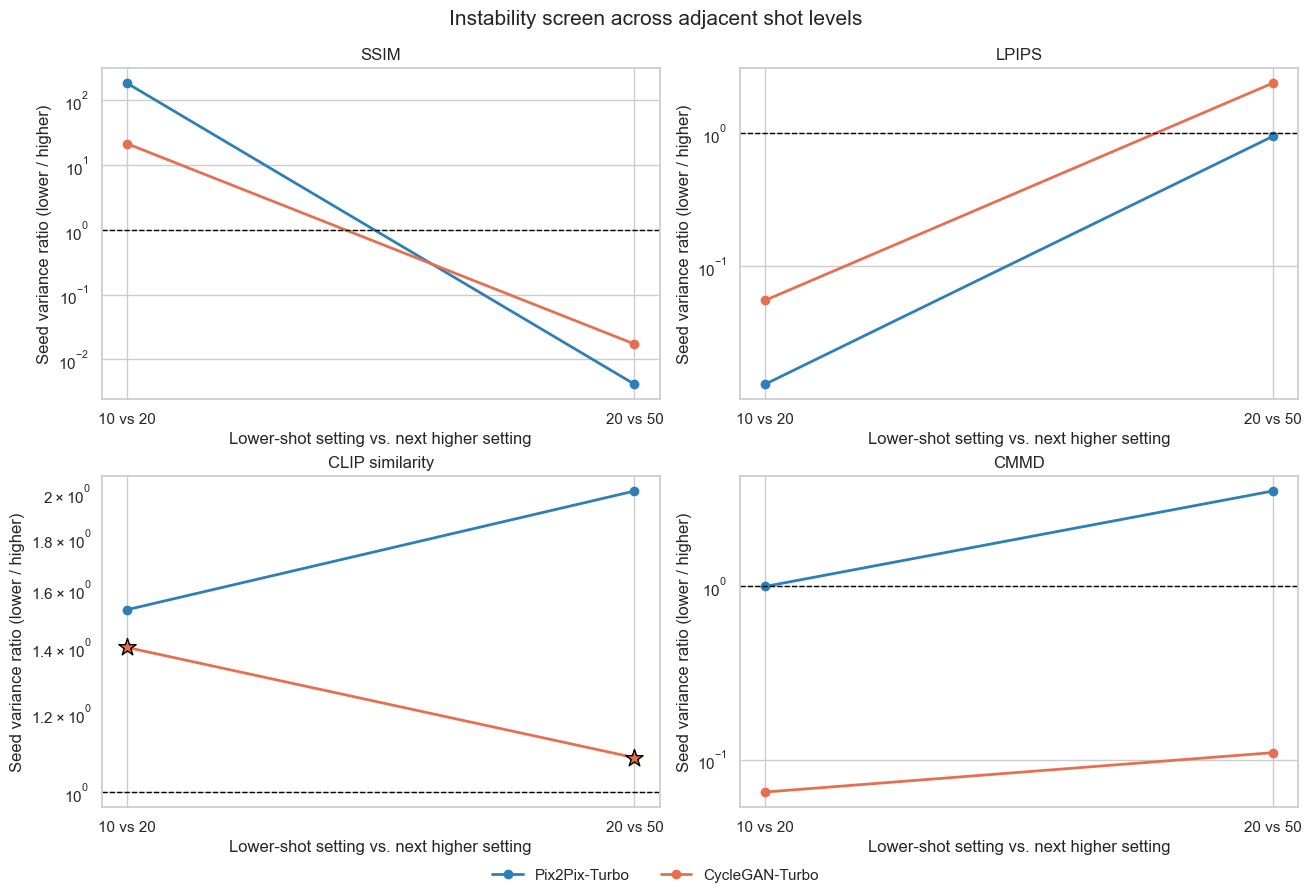

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)
for ax, (metric, meta) in zip(axes.flat, METRICS.items()):
    subset = breaking[breaking['metric'] == metric]
    for model in MODELS:
        model_rows = subset[subset['model'] == model].sort_values('low_shot')
        ax.plot(
            model_rows['comparison'], model_rows['seed_variance_ratio'],
            marker='o', linewidth=2, color=MODEL_COLORS[model],
            label=MODEL_LABELS[model],
        )
        candidates = model_rows['seed_level_candidate']
        ax.scatter(
            model_rows.loc[candidates, 'comparison'],
            model_rows.loc[candidates, 'seed_variance_ratio'],
            marker='*', s=170, color=MODEL_COLORS[model], edgecolor='black', zorder=4,
        )
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_yscale('log')
    ax.set_title(meta['label'])
    ax.set_xlabel('Lower-shot setting vs. next higher setting')
    ax.set_ylabel('Seed variance ratio (lower / higher)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=2, frameon=False)
fig.suptitle('Instability screen across adjacent shot levels', y=1.04, fontsize=15)
plt.show()

### Optional test-sample variance

The checked-in aggregate files contain one mean per seed, so they support between-seed variance but not within-test-sample variance. If the full results archive is extracted at `results/full_grid_5090/evaluation/`, the next cell automatically loads the 18 `per_sample_metrics.csv` files and adds a descriptive within-seed sample-variance ratio. CMMD remains distribution-level and has no per-sample value.

In [10]:
evaluation_root = ROOT / 'results' / 'full_grid_5090' / 'evaluation'
sample_files = sorted(evaluation_root.glob('*/*shot/seed*/per_sample_metrics.csv'))

if not sample_files:
    print(
        'Per-sample files not found. Extract the full artifact under '
        'results/full_grid_5090/evaluation to complete criterion (2).'
    )
else:
    frames = []
    for path in sample_files:
        relative = path.relative_to(evaluation_root)
        model, shot_folder, seed_folder = relative.parts[:3]
        frame = pd.read_csv(path)
        frame['model'] = model
        frame['shot'] = int(shot_folder.removesuffix('shot'))
        frame['seed'] = int(seed_folder.removeprefix('seed'))
        frames.append(frame)
    samples = pd.concat(frames, ignore_index=True)

    sample_rows = []
    for metric in ('ssim', 'lpips', 'clip_similarity'):
        within_seed = (
            samples.groupby(['model', 'shot', 'seed'])[metric]
            .var(ddof=1)
            .groupby(['model', 'shot'])
            .mean()
        )
        for model in MODELS:
            for low_shot, high_shot in ((10, 20), (20, 50)):
                low_variance = within_seed.loc[(model, low_shot)]
                high_variance = within_seed.loc[(model, high_shot)]
                sample_rows.append({
                    'model': model,
                    'metric': metric,
                    'low_shot': low_shot,
                    'sample_variance_ratio': low_variance / high_variance,
                })

    sample_variance = pd.DataFrame(sample_rows)
    breaking = breaking.merge(
        sample_variance, on=['model', 'metric', 'low_shot'], how='left'
    )
    breaking['sample_variance_status'] = np.select(
        [
            breaking['sample_variance_ratio'].isna(),
            breaking['sample_variance_ratio'] > 1,
        ],
        ['N/A (distribution-level metric)', 'increases'],
        default='does not increase',
    )
    breaking['full_breaking_point_evidence'] = pd.Series(
        pd.NA, index=breaking.index, dtype='boolean'
    )
    sample_available = breaking['sample_variance_ratio'].notna()
    breaking.loc[sample_available, 'full_breaking_point_evidence'] = (
        breaking.loc[sample_available, 'raw_significant']
        & breaking.loc[sample_available, 'seed_variance_increases']
        & (breaking.loc[sample_available, 'sample_variance_ratio'] > 1)
    )
    display(
        breaking.sort_values(['model', 'metric', 'low_shot']).style.format({
            'p_raw': '{:.4f}',
            'p_holm': '{:.4f}',
            'seed_variance_ratio': '{:.2f}',
            'sample_variance_ratio': '{:.2f}',
        }, na_rep='N/A')
    )

,model,metric,comparison,low_shot,high_shot,degradation,p_raw,seed_variance_ratio,p_holm,mean_degrades,raw_significant,holm_significant,seed_variance_increases,seed_level_candidate,sample_variance_ratio,sample_variance_status,full_breaking_point_evidence
12,cyclegan,clip_similarity,10 vs 20,10,20,0.012626,0.0083,1.40,0.0665,True,True,False,True,True,1.12,increases,True
13,cyclegan,clip_similarity,20 vs 50,20,50,0.000831,0.0285,1.08,0.1707,True,True,False,True,True,0.94,does not increase,False
14,cyclegan,cmmd,10 vs 20,10,20,0.005493,0.0148,0.07,0.1038,True,True,False,False,False,N/A,N/A (distribution-level metric),N/A
15,cyclegan,cmmd,20 vs 50,20,50,-0.001088,0.6159,0.11,1.0000,False,False,False,False,False,N/A,N/A (distribution-level metric),N/A
10,cyclegan,lpips,10 vs 20,10,20,0.007052,0.2758,0.06,1.0000,True,False,False,False,False,1.28,increases,False
11,cyclegan,lpips,20 vs 50,20,50,0.000019,0.4981,2.37,1.0000,True,False,False,True,False,0.88,does not increase,False
8,cyclegan,ssim,10 vs 20,10,20,0.016862,0.0866,21.48,0.4331,True,False,False,True,False,1.44,increases,False
9,cyclegan,ssim,20 vs 50,20,50,0.008913,0.2857,0.02,1.0000,True,False,False,False,False,0.91,does not increase,False
4,pix2pix,clip_similarity,10 vs 20,10,20,0.006912,0.1180,1.53,0.7082,True,False,False,True,False,1.23,increases,False
5,pix2pix,clip_similarity,20 vs 50,20,50,0.000452,0.3773,2.01,1.0000,True,False,False,True,False,0.95,does not increase,False


## Interpretation guidance

- Treat a metric-specific shot level as a **descriptive instability candidate** when the raw paired test shows degradation and the seed variance ratio exceeds 1.
- Call it a **formal breaking point** only when the claim is also supported by test-sample variability and remains credible after accounting for multiple comparisons.
- With only three seeds, failure to reach significance is not evidence that the models are stable; report effect direction, variance ratios, and uncertainty alongside p-values.
- Do not pool 600 sample rows as if they were 600 independent training runs. Images are repeated across seeds and shot levels, so per-sample evidence must remain grouped by seed.
- Use the same 200 filenames for every model/shot/seed comparison, as enforced by the generation manifests.

## Human qualitative evaluation

To complement the quantitative breaking-point analysis, score a filename-matched subset blind to model and shot level. Use the same images across all conditions and randomize presentation order.

| Aspect | Score (1–5) | Evaluation focus |
| :--- | :--- | :--- |
| **Instruction following / content preservation** | 1 = major content mismatch; 5 = core scene content preserved while following the day-to-night instruction | Whether vehicles, roads, signs, and scene layout remain faithful to the input |
| **Physical and spatial logic** | 1 = severe geometry/physics errors; 5 = natural and coherent scene | Road geometry, vehicle structure, lighting placement, and spatial consistency |
| **Visual quality** | 1 = severe blur/noise/artifacts; 5 = sharp and natural | Artifacts, sharpness, color, exposure, and local texture |
| **Night realism** | 1 = not convincingly nighttime; 5 = realistic nighttime appearance | Darkness, illumination, headlights, shadows, and overall atmosphere |